# Diabetic retinopathy diagnosis using deep neural networks

**Experiment Notebook**  
Author: Yelizaveta Kabanova  
Date: 2025/2026

This notebook trains and evaluates CNN models for diabetic retinopathy classification on fundus images.

## Imports

In [1]:
!pip install keras_preprocessing
!pip install tf_keras_vis

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.6/42.6 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.5/52.5 kB 5.0 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import cv2
import os
import pathlib
import shutil
import matplotlib.pyplot as plt
import seaborn as sns
import random
import pickle
import time
import gc
import warnings
from PIL import Image
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import label_binarize
from sklearn.metrics import (precision_score, accuracy_score, recall_score,
                             f1_score, cohen_kappa_score, roc_auc_score,
                             classification_report, confusion_matrix,
                             f1_score, roc_auc_score, roc_curve,
                             auc, balanced_accuracy_score
                            )
import tensorflow as tf
from tensorflow.keras import backend as K
from tensorflow.keras import Model
from keras_preprocessing.image import ImageDataGenerator
from tf_keras_vis.saliency import Saliency
from tf_keras_vis.utils.scores import CategoricalScore
from tf_keras_vis.utils.model_modifiers import ReplaceToLinear
from tf_keras_vis.gradcam import Gradcam
from tf_keras_vis.utils.model_modifiers import ReplaceToLinear
from tf_keras_vis.utils.scores import CategoricalScore

sns.set_style("darkgrid")
sns.set_theme(palette="muted")

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'

K.clear_session()
tf.compat.v1.reset_default_graph()

## Configuration

In [3]:
# ===============================
# Variables
# ===============================
# == path ==
# DATA_DIR = pathlib.Path(r"C:\Users\eliza\Portfolio\blindness-detection")
# RAW_DIR = DATA_DIR / "train_images"
# TRAIN_CSV = DATA_DIR / 'train.csv'
# PROC_DIR = DATA_DIR / "train_images_proc_v2"   # advanced preprocessing
# BAL_DIR = DATA_DIR / 'train_images_bal_v2'     # oversampling + advanced preprocessing
# RESULTS_PATH = "training_results.csv"
# TEST_RESULTS_PATH = "test_experiment_results.csv"

# == Path for google Collab ==
from google.colab import drive
drive.mount('/content/drive')
DATA_DIR = pathlib.Path("/content/drive/MyDrive/Blindness-Detection")
RAW_DIR = DATA_DIR / "train_images"
TRAIN_CSV = DATA_DIR / 'train.csv'

PROC_DIR = DATA_DIR / "train_images_proc_v2"

BAL_DIR  = DATA_DIR / "train_images_bal_v2"

RESULTS_PATH = DATA_DIR / "training_results.csv"
TEST_RESULTS_PATH = DATA_DIR / "test_experiment_results.csv"

# == constants ==
IMG_CHANNELS = 3
IMG_SIZE = 224
BATCH_SIZE = 32
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
EPOCHS = 30
NUM_CLASSES = 5
class_names = {
    0: "No DR",
    1: "Mild DR",
    2: "Moderate DR",
    3: "Severe DR",
    4: "Proliferative DR"
}

Mounted at /content/drive


In [4]:
# ============================================================
# Load Dataset
# ============================================================
train_full_df = pd.read_csv(TRAIN_CSV)

train_full_df['diagnosis_label'] = train_full_df['diagnosis'].map(class_names)
train_full_df["image_path"] = train_full_df["id_code"].apply(
    lambda x: str(DATA_DIR / "train_images" / f"{x}.png")
)

## Load Processed Images

In [5]:
# ============================================================
# Load Processed Images
# ==========================================================
def load_processed_images(proc_dir, train_csv):
    base_df = pd.read_csv(train_csv)
    diagnosis_map = dict(zip(base_df['id_code'], base_df['diagnosis']))
    image_files = sorted([f for f in os.listdir(proc_dir) if f.endswith(".png")])

    records = []
    for fname in image_files:
        id_code = fname.replace(".png", "")
        if id_code in diagnosis_map:
            diagnosis = diagnosis_map[id_code]
        else:
            base_id = id_code.split("_aug_")[0]
            diagnosis = diagnosis_map.get(base_id, np.nan)
        records.append({
            "id_code": id_code,
            "diagnosis": diagnosis,
            "image_path": str(proc_dir / fname)
        })
    df = pd.DataFrame(records)
    print(f"--- Loaded {len(df)} images from {os.path.basename(proc_dir)} ---")
    return df

## Data Split

In [6]:
# ============================================================
# Train / Validation Split
# ============================================================
def split_train_val(df, seed=SEED):
    train_df, val_df = train_test_split(
        df,
        test_size=0.2,
        stratify=df['diagnosis'],
        random_state=seed
    )
    return train_df.reset_index(drop=True), val_df.reset_index(drop=True)

# ============================================================
# Data Generators
# ============================================================
def make_train_val_generators(train_df, val_df, img_size=IMG_SIZE, batch_size=BATCH_SIZE, seed=SEED):
    train_datagen = ImageDataGenerator(
        rescale=1./255,
        horizontal_flip=True,
        rotation_range=10,
        width_shift_range=0.1,
        height_shift_range=0.1,
        zoom_range=0.1,
        brightness_range=[0.8, 1.2],
        fill_mode='nearest'
    )

    val_datagen = ImageDataGenerator(
        rescale=1./255
    )

    train_df['diagnosis'] = train_df['diagnosis'].astype(str)
    val_df['diagnosis'] = val_df['diagnosis'].astype(str)

    train_gen = train_datagen.flow_from_dataframe(
        dataframe=train_df,
        x_col='image_path',
        y_col='diagnosis',
        target_size=(img_size, img_size),
        batch_size=batch_size,
        class_mode='categorical',
        shuffle=True,
        color_mode='rgb',
        seed=SEED
    )

    val_gen = val_datagen.flow_from_dataframe(
        dataframe=val_df,
        x_col='image_path',
        y_col='diagnosis',
        target_size=(img_size, img_size),
        batch_size=batch_size,
        class_mode='categorical',
        shuffle=False,
        color_mode='rgb'
    )
    return train_gen, val_gen

## Model

In [7]:
# ==========================================
# CNN Trainer
# ==========================================

class CNN_build():
    # ---------- Initialization ----------
    def __init__(self, model=None, save_dir=DATA_DIR / 'models'):
        self.model = model
        self.history = None
        self.save_dir =  save_dir
        if not os.path.exists(save_dir):
            os.makedirs(save_dir)

    # ---------- Model Setup ----------
    def compile(self, optimizer, loss, metrics, loss_weights=None):
        if self.model is None:
            raise ValueError("--- Model is not defined ---")
        self.model.compile(optimizer=optimizer, loss=loss, metrics=metrics, loss_weights=loss_weights)

    # ---------- Training ----------
    def fit(self, train, val, class_weight=None, callbacks=None, epochs=EPOCHS, model_name='model'):
        callbacks = callbacks or []
        start = time.time()
        self.history = self.model.fit( # type: ignore
            train, validation_data=val,
            class_weight=class_weight,
            callbacks=callbacks,
            epochs=epochs, verbose=1
        )
        end = time.time()
        training_time = (end - start) / 60

        model_path = os.path.join(self.save_dir, f'{model_name}.keras')
        self.model.save(model_path) # type: ignore
        print(f'\n--- Model {model_name} saved to {model_path} ---')

        history_path = os.path.join(self.save_dir, f'{model_name}_history.pkl')
        with open(history_path, 'wb') as f:
            hist_dict = getattr(self.history, 'history', self.history)
            pickle.dump(hist_dict, f)
        print(f'\n--- History of {model_name} saved to {history_path} ---')
        return getattr(self.history, 'history', self.history)

    # ---------- Efficiency Metrics ----------
    def measure_latency_ms(self, img_size=IMG_SIZE, device=None, repeats=50, warmup=10):
        context = tf.device(device) if device else None
        with context: # type: ignore
            x = tf.random.uniform([1, img_size, img_size, 3])
            for _ in range(warmup):
                _ = self.model(x, training=False).numpy() # type: ignore
            times = []
            for _ in range(repeats):
                t0 = time.perf_counter()
                _ = self.model(x, training=False).numpy() # type: ignore
                times.append((time.perf_counter() - t0) * 1000.0)
        return float(np.median(times))

    def estimate_memory_usage(self, batch_size=1):
        param_mem = self.model.count_params() * 4 / (1024**2)  # type: ignore # MB
        input_mem = np.prod(self.model.input_shape[1:]) * batch_size * 4 / (1024**2) # type: ignore
        return param_mem + input_mem

    def efficiency_ratio(self, acc, params_m, latency_ms):
        return (acc * 100) / (latency_ms + params_m)

    # ---------- Reliability Metrics ----------
    def compute_reliability_score(self, qwk, mean_entropy, mean_confidence, num_classes,
                                  alpha=1, beta=0.5, gamma=0.5, eps=1e-8):
        if np.isnan(qwk) or np.isnan(mean_entropy) or np.isnan(mean_confidence):
            return np.nan

        h_norm = mean_entropy / np.log(num_classes)
        h_norm = np.clip(h_norm, 0, 1)

        rs = np.exp(
            alpha * np.log(qwk + eps) +
            beta  * np.log(1 - h_norm + eps) +
            gamma * np.log(mean_confidence + eps)
        )
        return float(rs)

    # ---------- Evaluation ----------
    def evaluate(self, test_set, mc_dropout=False, n_passes=5):
        results = self.model.evaluate(test_set, return_dict=True) # type: ignore
        total_params_m = self.model.count_params() / 1e6              # type: ignore # total parameters
        mem_mb = self.estimate_memory_usage()                     #memory

        try:
            lat_gpu = self.measure_latency_ms(device='/GPU:0')  # Latency
        except Exception:
            lat_gpu = None
        lat_cpu = self.measure_latency_ms(device='/CPU:0')

        acc_key =  'accuracy'
        acc_value = results.get(acc_key, 0)

        er_cpu = self.efficiency_ratio(acc_value, total_params_m, lat_cpu) # ER
        er_gpu = None if lat_gpu is None else self.efficiency_ratio(acc_value, total_params_m, lat_gpu)

        results['Params (M)'] = total_params_m
        results['Memory (MB)'] = mem_mb
        results['Latency CPU (ms)'] = lat_cpu
        results['Latency GPU (ms)'] = lat_gpu
        results['Efficiency Ratio CPU'] = er_cpu
        results['Efficiency Ratio GPU'] = er_gpu

        results = {k: (round(v, 4) if isinstance(v, (int, float)) else v) for k, v in results.items()}
        print("\n| " + " | ".join(f"{k}: {v:.4f}" if isinstance(v, (int, float)) else f"{k}: {v}" for k, v in results.items()))
        return results

    def post_training_metrics(self, test_set, class_labels, n_images, model_name):
        y_true = test_set.classes
        y_pred_prob = self.model.predict(test_set, verbose=0)   # type: ignore
        y_pred = np.argmax(y_pred_prob, axis=1)

        qwk = cohen_kappa_score(y_true, y_pred, weights="quadratic") # type: ignore
        bal_acc = balanced_accuracy_score(y_true, y_pred)
        precision = precision_score(y_true, y_pred, average='macro', zero_division=0)
        recall = recall_score(y_true, y_pred, average='macro', zero_division=0)
        f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
        cm = confusion_matrix(y_true, y_pred)
        report = classification_report(y_true, y_pred, digits=4)

        self.plot_confusion_matrix(cm / cm.sum(axis=1)[:, np.newaxis], class_labels, model_name)
        y_true_bin = label_binarize(y_true, classes=np.unique(y_true))
        self.plot_roc_curve(y_true_bin, y_pred_prob, class_labels, model_name)
        self.plot_sample_predictions(test_set, y_true, y_pred, class_labels, n_images, model_name)

        row = {
            'QWK': qwk,
            'Accuracy (B)': bal_acc,
            'Precision (Macro)': precision,
            'Recall (Macro)': recall,
            'F1 Score (Macro)': f1,
        }
        row = {k: (round(v, 4) if isinstance(v, (int, float)) else v) for k, v in row.items()}
        print("\n| " + " | ".join(f"{k}: {v:.4f}" if isinstance(v, (int, float)) else f"{k}: {v}" for k, v in row.items()))
        return row

    # ---------- Inference ----------
    def predict(self, test_set):
        pred = self.model.predict(test_set) # pyright: ignore[reportOptionalMemberAccess]
        return np.argmax(pred, axis=-1)

    def monte_carlo_dropout_full(self, test_gen, n_passes):
        """
        https://arxiv.org/pdf/1703.04977
        Monte Carlo Dropout для всього тестового набору, batch_size з ImageDataGenerator
        CPU-friendly, без OOM
        """
        print(f"\n--- MC Dropout inference: {n_passes} stochastic passes ---")

        n_samples = test_gen.samples
        num_classes = self.model.output_shape[-1] # type: ignore

        all_preds = []
        for pass_idx in range(n_passes):
            print(f"Pass {pass_idx + 1}/{n_passes}")
            test_gen.reset()
            preds_pass = []
            for batch_x, _ in test_gen:
                preds = self.model(batch_x, training=True).numpy() # type: ignore
                preds_pass.append(preds)
                del batch_x, preds
                gc.collect()
                if sum(p.shape[0] for p in preds_pass) >= n_samples:
                    break
            preds_pass = np.concatenate(preds_pass, axis=0)[:n_samples]
            all_preds.append(preds_pass)
        all_preds = np.array(all_preds, dtype=np.float32)

        mean_pred = all_preds.mean(axis=0)
        var_pred = all_preds.var(axis=0)

        eps = 1e-12
        entropy = -np.sum(mean_pred * np.log(mean_pred + eps), axis=1)
        confidence = np.max(mean_pred, axis=1)

        return {
            "mean_pred": mean_pred,
            "var_pred": var_pred,
            "entropy": entropy,
            "mean_entropy": float(np.mean(entropy)),
            "confidence": confidence,
            "mean_confidence": float(np.mean(confidence)),
        }

    # ---------- Visualizations ----------
    def training_plot(self, metrics=None, include_val=True, save_path=None):
        if self.history is None:
            raise ValueError("\n--- No history found. Fit the model first ---")

        all_keys = list(self.history.history.keys())
        ignore = ['lr', 'learning_rate']
        all_keys = [k for k in all_keys if not any(ig in k for ig in ignore)]

        if metrics is None:
            metrics_to_plot = sorted(set(
                k.replace('val_', '') for k in all_keys
            ))
        else:
            metrics_to_plot = [
                m for m in metrics
                if m in self.history.history or f'val_{m}' in self.history.history
            ]

        if not metrics_to_plot:
            print("\n--- No valid metrics available to plot ---")
            print("Available keys:", all_keys)
            return

        fig, ax = plt.subplots(len(metrics_to_plot), 1, figsize=(7, len(metrics_to_plot) * 4))
        if len(metrics_to_plot) == 1:
            ax = [ax]

        for idx, metric in enumerate(metrics_to_plot):
            if metric in self.history.history:
                ax[idx].plot(self.history.history[metric], label=f"train_{metric}", color='teal', linestyle='--')
            if include_val and f'val_{metric}' in self.history.history:
                ax[idx].plot(self.history.history[f'val_{metric}'], label=f"val_{metric}", color='orange')
            ax[idx].set_xlabel('Epochs')
            ax[idx].set_title(metric.replace('_', ' ').capitalize(), fontsize=12, weight="bold")
            ax[idx].legend(loc="upper left")
            ax[idx].grid(alpha=0.6)

        plt.tight_layout()

        if save_path:
            os.makedirs(os.path.dirname(save_path), exist_ok=True)
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
            print(f"--- Training curves saved to {save_path} ---")

        plt.show()
        plt.close(fig)

    def plot_confusion_matrix(self, cm, class_labels, model_name):
        plt.figure(figsize=(7,6))
        sns.heatmap(cm, annot=True, fmt=".2f", cmap='Blues',
                    xticklabels=class_labels, yticklabels=class_labels)
        plt.ylabel('Actual')
        plt.xlabel('Predicted')
        plt.title(f'Confusion Matrix\n{model_name}', fontsize=12, weight="bold")
        plt.tight_layout()
        plt.show()

    def plot_roc_curve(self, y_true_bin, y_pred_proba, class_labels, model_name):
        plt.figure(figsize=(10,6))
        n_classes = y_true_bin.shape[1]
        for i in range(n_classes):
            fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred_proba[:, i])
            roc_auc_val = auc(fpr, tpr)
            plt.plot(fpr, tpr, label=f"{class_labels[i]} (AUC = {roc_auc_val :.3f})")
        plt.plot([0,1],[0,1], "k--")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title(f"ROC Curve\n{model_name}", fontsize=12, weight="bold")
        plt.legend(loc="lower right")
        plt.grid(alpha=0.5)
        plt.show()

    def plot_sample_predictions(self, test_set, y_true, y_pred, class_labels, n_images, model_name):
        correct_idx = np.where(y_true == y_pred)[0]
        wrong_idx   = np.where(y_true != y_pred)[0]

        half = n_images // 2
        chosen_idx = []
        if len(correct_idx) > 0:
            chosen_idx.extend(np.random.choice(correct_idx, min(half, len(correct_idx)), replace=False))
        if len(wrong_idx) > 0:
            chosen_idx.extend(np.random.choice(wrong_idx, min(n_images-half, len(wrong_idx)), replace=False))
        chosen_idx = np.array(chosen_idx)

        plt.figure(figsize=(10, 10))
        for k, idx in enumerate(chosen_idx):
            batch_idx = idx // test_set.batch_size
            img_idx   = idx % test_set.batch_size
            imgs, _   = test_set[batch_idx]
            img       = imgs[img_idx]

            cols = 3
            rows = int(np.ceil(n_images / cols))
            plt.subplot(rows, cols, k+1)
            plt.imshow((img*255).astype("uint8"))
            plt.axis("off")

            color = "green" if y_true[idx]==y_pred[idx] else "red"
            plt.title(f"T:{class_labels[y_true[idx]]}\nP:{class_labels[y_pred[idx]]}",
                    fontsize=10, color=color, weight="bold")

        plt.suptitle(f"Sample Predictions\n{model_name}", fontsize=12, weight="bold")
        plt.tight_layout()
        plt.show()

    # ---------- Explainability ----------
    def saliency_maps(self, test_set, class_labels, n_images, model_name):
        images = []
        labels_true = []
        test_set.reset()
        current_count = 0

        for batch_x, batch_y in test_set:
            batch_size = batch_x.shape[0]
            take_count = min(batch_size, n_images - current_count)
            images.append(batch_x[:take_count])
            labels_true.append(np.argmax(batch_y[:take_count], axis=-1))
            current_count += take_count
            if current_count >= n_images:
                break

        images = np.concatenate(images)
        labels_true = np.concatenate(labels_true)

        if len(images) < n_images:
            n_images = len(images)

        predictions = self.model.predict(images, verbose=0) # type: ignore
        labels_pred = np.argmax(predictions, axis=1)
        idxs = np.random.choice(len(images), size=n_images, replace=False)

        saliency = Saliency(
            self.model,
            model_modifier=ReplaceToLinear(),
            clone=True
        )

        n_rows = n_images
        n_cols = 2
        plt.figure(figsize=(4.5 * n_cols, 4.5 * n_rows))
        for i, idx in enumerate(idxs):
            image = images[idx:idx+1]
            pred_label_idx = labels_pred[idx]

            score = CategoricalScore([pred_label_idx])
            saliency_map = saliency(score, image, smooth_samples=20, smooth_noise=0.2)
            saliency_map = saliency_map[0]

            ax1 = plt.subplot(n_rows, n_cols, i*2 + 1)
            ax1.imshow((image[0] * 255).astype("uint8"))
            ax1.axis("off")
            is_correct = (labels_true[idx] == labels_pred[idx])
            color = 'green' if is_correct else 'red'
            ax1.set_title(f"T: {class_labels[labels_true[idx]]} | P: {class_labels[pred_label_idx]}", color=color)

            ax2 = plt.subplot(n_rows, n_cols, i*2 + 2)
            ax2.imshow(image[0])
            im = ax2.imshow(saliency_map, cmap='jet', alpha=0.7)
            ax2.axis("off")
            ax2.set_title('Saliency Map')

        plt.suptitle(f"Saliency Maps (SmoothGrad)\n{model_name}", fontsize=12, weight="bold")
        plt.tight_layout()
        plt.show()

    # ---------- Utilities ----------
    def training_df(self):
        if self.history is None:
            raise ValueError("\n--- No history found. Fit the model first ---")
        return pd.DataFrame(self.history.history)

    def load_model(self, model_name):
        model_path = self.save_dir / f'{model_name}.keras'
        if not os.path.exists(model_path):
            raise FileNotFoundError(f"\n--- Model not found at {model_path} ---")
        self.model = tf.keras.models.load_model(model_path)
        print(f'\n--- Model loaded for {model_name} ---')

    def load_history(self, model_name):
        history_path = self.save_dir / f"{model_name}_history.pkl"
        if not os.path.exists(history_path):
            raise FileNotFoundError(f"\n--- History not found at {history_path} ---")
        with open(history_path, 'rb') as f:
            self.history = pickle.load(f)
        print(f'\n--- Model and history loaded for {model_name} ---')

## Experiment

In [8]:
# =======================================
# CBAM Attention Block
# ======================================
@tf.keras.utils.register_keras_serializable(package="custom_layers")
def channel_avg(x):
    return tf.reduce_mean(x, axis=3, keepdims=True)

@tf.keras.utils.register_keras_serializable(package="custom_layers")
def channel_max(x):
    return tf.reduce_max(x, axis=3, keepdims=True)

def cbam_block(feature_map, ratio=8):
    """
    CBAM: Channel + Spatial attention.
    """

    # ---------- Channel Attention ----------
    channel = feature_map.shape[-1]
    avg_pool = tf.keras.layers.GlobalAveragePooling2D()(feature_map)
    max_pool = tf.keras.layers.GlobalMaxPooling2D()(feature_map)

    avg_dense = tf.keras.layers.Dense(channel // ratio, activation='relu')(avg_pool)
    avg_dense = tf.keras.layers.Dense(channel, activation='sigmoid')(avg_dense)
    max_dense = tf.keras.layers.Dense(channel // ratio, activation='relu')(max_pool)
    max_dense = tf.keras.layers.Dense(channel, activation='sigmoid')(max_dense)

    channel_attention = tf.keras.layers.Add()([avg_dense, max_dense])
    channel_attention = tf.keras.layers.Activation('sigmoid')(channel_attention)
    channel_attention = tf.keras.layers.Reshape((1, 1, channel))(channel_attention)
    channel_refined = tf.keras.layers.Multiply()([feature_map, channel_attention])

    # ---------- Spatial Attention ----------
    avg_pool_spatial = tf.keras.layers.Lambda(channel_avg, name='spatial_avg')(channel_refined)
    max_pool_spatial = tf.keras.layers.Lambda(channel_max, name='spatial_max')(channel_refined)
    concat = tf.keras.layers.Concatenate(axis=3)([avg_pool_spatial, max_pool_spatial])
    spatial_attention = tf.keras.layers.Conv2D(filters=1, kernel_size=7, padding='same', activation='sigmoid')(concat)
    refined_feature = tf.keras.layers.Multiply()([channel_refined, spatial_attention])
    return refined_feature

In [9]:
# ======================================
# Adaptive CBAM
# ======================================

@tf.keras.utils.register_keras_serializable() # pyright: ignore[reportAttributeAccessIssue]
class AdaptiveCBAM(tf.keras.layers.Layer): # type: ignore
    def __init__(self, base_ratio=8, min_ratio=4, max_ratio=16, **kwargs):
        super().__init__(**kwargs)
        self.base_ratio = base_ratio
        self.min_ratio = min_ratio
        self.max_ratio = max_ratio

    def build(self, input_shape):
        self.channel = input_shape[-1]
        self.hidden_units = max(1, self.channel // self.base_ratio)

        # ---------- Channel Attention ----------
        self.fc1 = tf.keras.layers.Dense(self.hidden_units, activation='relu') # type: ignore
        self.fc2 = tf.keras.layers.Dense(self.channel, activation='sigmoid') # type: ignore

        # ---------- Spatial Attention ----------
        self.spatial_conv = tf.keras.layers.Conv2D(1, kernel_size=7, padding='same', activation='sigmoid') # type: ignore
        super().build(input_shape)

    def call(self, x):
        # ---------- Channel Attention ----------
        var_per_channel = tf.reduce_mean(tf.math.reduce_variance(x, axis=[1,2]), axis=0)
        var_score = tf.reduce_mean(var_per_channel)
        adaptive_scale = tf.clip_by_value(1.0 + var_score, 1.0, 2.0)
        avg_pool = tf.reduce_mean(x, axis=[1,2])
        max_pool = tf.reduce_max(x, axis=[1,2])
        avg_out = self.fc2(self.fc1(avg_pool))
        max_out = self.fc2(self.fc1(max_pool))
        channel_attention = tf.keras.activations.sigmoid(avg_out + max_out) # type: ignore
        channel_attention = tf.reshape(channel_attention, [-1, 1, 1, self.channel])
        x = x * channel_attention * adaptive_scale

        # ---------- Spatial Attention ----------
        avg_pool_spatial = tf.reduce_mean(x, axis=3, keepdims=True)
        max_pool_spatial = tf.reduce_max(x, axis=3, keepdims=True)
        concat = tf.concat([avg_pool_spatial, max_pool_spatial], axis=3)
        spatial_attention = self.spatial_conv(concat)
        x = x * spatial_attention * adaptive_scale
        return x

In [10]:
# ============================================================
# Transfer learning + Focal Loss + AdaptiveCBAM  + MC Dropout
# ============================================================
def build_mc_acbam_model_extra(base, input_shape=(IMG_SIZE, IMG_SIZE, 3), num_classes=5):
    base_model = base(include_top=False, weights="imagenet", input_shape=input_shape)
    base_model.trainable = False
    inputs = base_model.input
    x = base_model.output
    x = tf.keras.layers.BatchNormalization()(x)
    x = AdaptiveCBAM(base_ratio=8)(x)
    x = AdaptiveCBAM(base_ratio=8)(x)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dense(256, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(1e-5))(x)
    x = tf.keras.layers.Dropout(0.3)(x, training=True)   # MC Dropout.
    outputs = tf.keras.layers.Dense(num_classes, activation='softmax')(x)
    model = tf.keras.Model(inputs, outputs)
    return model, base_model

## Evaluation

In [11]:
# =====================================
# Main Testing Function
# =====================================
def evaluate_test_set(model_name, exp_name, test_gen, n_passes, run_saliency=True):
    print(f"\n=== Running Final Test for {model_name} ({exp_name}) ===")

    class_labels = list(test_gen.class_indices.keys())
    cnn = CNN_build()

    try:
        cnn.load_model(f"{model_name}_best_by_kappa")
        print(f"--- Loaded model: {model_name}_best_by_kappa (optimized for QWK) ---")
    except FileNotFoundError:
        try:
            cnn.load_model(f"{model_name}_best")
            print(f"--- Loaded model: {model_name}_best (optimized for val_loss) ---")
        except FileNotFoundError:
            print(f"--- Error: Neither 'best_by_kappa' nor 'best' model found for {model_name} ---")
            return None

    try:
        mc_results = cnn.monte_carlo_dropout_full(test_gen, n_passes)
        uncertainty = mc_results["var_pred"].mean(axis=1)
        uncertainty_mean = round(uncertainty.mean(), 4)
        mean_entropy = round(mc_results["mean_entropy"], 4)
        mean_confidence = round(mc_results["mean_confidence"], 4)

    except Exception as e:
        print(f"--- Warning: MC Dropout failed for {model_name} ---\n{e}")
        uncertainty_mean = mean_entropy = mean_confidence = np.nan
        mc_results = None

    if mc_results is not None:
        # ---------- Histogram of Epistemic Uncertainty ----------
        plt.figure(figsize=(8,5))
        sns.histplot(uncertainty, bins=30, kde=True)
        plt.title(f"Epistemic Uncertainty Distribution (MC Dropout)\n{model_name}", fontsize=12, weight="bold")
        plt.xlabel("Mean Variance")
        plt.ylabel("Number of samples")
        plt.grid(alpha=0.5)
        plt.show()

        # ---------- Histogram of entropy ----------
        plt.figure(figsize=(8,5))
        sns.histplot(mc_results["entropy"], bins=30, kde=True)
        plt.title(f"Entropy Distribution (MC Dropout)\n{model_name}", fontsize=12, weight="bold")
        plt.xlabel("Entropy")
        plt.ylabel("Number of samples")
        plt.grid(alpha=0.5)
        plt.show()

        # ---------- Confidence vs Entropy Scatter ----------
        plt.figure(figsize=(8,5))
        sns.scatterplot(data=mc_results, x="confidence", y="entropy", alpha=0.6)
        plt.title(f"Confidence vs Entropy\n{model_name}", fontsize=12, weight="bold")
        plt.xlabel("Confidence")
        plt.ylabel("Entropy")
        plt.tight_layout()
        plt.show()

    test_results = cnn.post_training_metrics(test_gen, class_labels, n_images=6, model_name=model_name)
    reliability_score = cnn.compute_reliability_score(
        qwk=test_results.get("QWK", np.nan),
        mean_entropy=mean_entropy,
        mean_confidence=mean_confidence,
        num_classes=NUM_CLASSES
    )

    if run_saliency:
        cnn.saliency_maps(test_gen, class_labels, n_images=3, model_name=model_name)

    print(f"\n|Uncertainty: {uncertainty_mean}\n|Mean Entropy: {mean_entropy}\n|Mean Confidence: {mean_confidence}")
    print(f"|Reliability Score (RS): {reliability_score:.4f}")

    row = {
        "Model": model_name,
        "Experiment": exp_name,
        "Reliability Score": reliability_score,
        'MC Uncertainty': uncertainty_mean,
        "Mean Entropy": mean_entropy,
        "Mean Confidence": mean_confidence,
        **test_results
    }

    if os.path.exists(TEST_RESULTS_PATH):
        df = pd.read_csv(TEST_RESULTS_PATH)
        for col in row.keys():
            if col not in df.columns:
                df[col] = None
        for col in df.columns:
            if col not in row.keys():
                row[col] = None
    else:
        df = pd.DataFrame(columns=row.keys()) # type: ignore

    mask = (df['Model'] == row['Model']) & (df['Experiment'] == row['Experiment'])
    if mask.any():
        df.loc[mask, :] = pd.DataFrame([row])
    else:
        df = pd.concat([df, pd.DataFrame([row])], ignore_index=True)

    df = df.dropna(how='all')
    df.to_csv(TEST_RESULTS_PATH, index=False)
    print(f"\n--- Test Results updated and saved to {TEST_RESULTS_PATH} ---")
    return row

In [12]:
# ======================================
# Salency Map
# ======================================
def visualize_silency_map(model_name, exp_name, test_gen, n_images):
    print(f"\n=== Visualizing Saliency Maps for: {model_name} ({exp_name}) ===")
    class_labels = list(test_gen.class_indices.keys())
    cnn = CNN_build()
    try:
        cnn.load_model(f"{model_name}_best_by_kappa")
    except FileNotFoundError:
        try:
            cnn.load_model(f"{model_name}_best")
        except FileNotFoundError:
            print(f"--- Error: No model found for {model_name} ---")
            return None
    cnn.saliency_maps(test_gen, class_labels, n_images=n_images, model_name=model_name)

## Training

In [13]:
# =====================================
# Cohen Kappa Callback
# =====================================
class CohenKappaCallback(tf.keras.callbacks.Callback): # type: ignore
    def __init__(self, val_gen, save_dir, model_name):
        super().__init__()
        self.val_gen = val_gen
        self.save_dir = save_dir
        self.model_name = model_name
        self.best_kappa = -1

    def on_epoch_end(self, epoch, logs=None):
        if logs is None:
            logs = {}

        if hasattr(self.val_gen, "labels"):
            y_true = self.val_gen.labels
        else:
            y_true = np.concatenate([y for _, y in self.val_gen], axis=0)
            if y_true.ndim > 1:
                y_true = y_true.argmax(axis=1)

        y_pred = self.model.predict(self.val_gen, verbose=0)
        y_pred_classes = y_pred.argmax(axis=1)

        kappa = cohen_kappa_score(y_true, y_pred_classes, weights="quadratic")
        print(f"\nEpoch {epoch+1}: val_kappa = {kappa:.4f}")

        logs["val_kappa"] = kappa # type: ignore
        # self.model.history.history.setdefault("val_kappa", []).append(kappa)

        if kappa > self.best_kappa:
            self.best_kappa = kappa
            save_path = os.path.join(self.save_dir, f"{self.model_name}_best_by_kappa.keras")
            self.model.save(save_path)
            print(f"Validation Kappa improved. Model saved to {save_path}")

In [14]:
# =======================================
# CNN Connection Function
# =======================================
def train_experiment(model, model_name, train_gen, val_gen,
                   class_weight=None, optimizer=None, loss_fn=None, metrics=None,
                   epochs=EPOCHS, exp_name=None, mc_dropout=False):
    print("\n\n==============================================")
    print(f' Training {model_name} ')
    print("==================================================\n")

    metrics = metrics or [
        'accuracy',
        tf.keras.metrics.Precision(name='precision'), # type: ignore
        tf.keras.metrics.Recall(name='recall'), # type: ignore
        tf.keras.metrics.F1Score(name='f1_score', average='macro'), # type: ignore
        tf.keras.metrics.AUC(name="auc", multi_label=True, num_labels=5, from_logits=False) # type: ignore
    ]

    cnn = CNN_build(model)
    cnn.compile(optimizer=optimizer, loss=loss_fn, metrics=metrics)

    early_stopping = tf.keras.callbacks.EarlyStopping( # type: ignore
        monitor="val_loss", mode="min", patience=5, restore_best_weights=True, verbose=1
    )
    reduce_lr = tf.keras.callbacks.ReduceLROnPlateau( # type: ignore
        monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1
    )
    checkpoint_path = os.path.join(cnn.save_dir, f"{model_name}_best.keras")
    checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
        filepath=checkpoint_path, monitor="val_kappa", mode="max",save_best_only=True, verbose=1
    )

    try:
        kappa_cb = CohenKappaCallback(val_gen, cnn.save_dir, model_name)
        callbacks=[early_stopping, reduce_lr, checkpoint_cb, kappa_cb]
    except:
        callbacks=[early_stopping, reduce_lr, checkpoint_cb]

    start = time.time()
    history = cnn.fit(
      train_gen, val_gen, class_weight=class_weight,
      callbacks=callbacks, epochs=epochs, model_name=model_name
    )
    training_time = (time.time() - start) / 60

    plots_dir = os.path.join(cnn.save_dir, 'plots')
    os.makedirs(plots_dir, exist_ok=True)
    cnn.training_plot(save_path=os.path.join(plots_dir, f"{model_name}_curves.png"))

    custom_objects = {"AdaptiveCBAM": AdaptiveCBAM}
    cnn.model = tf.keras.models.load_model(checkpoint_path, custom_objects=custom_objects)
    results = cnn.evaluate(val_gen, mc_dropout=mc_dropout)

    model_df = cnn.training_df()
    row = {
        "Model": model_name,
        "Experiment": exp_name,
        "Val_Loss": results["loss"],
        "Val_Accuracy": results.get("accuracy"),
        "Val_Precision": results.get("precision", None),
        "Val_Recall": results.get("recall", None),
        "Val_F1": results.get("f1_score", None),
        "Val_AUC": results.get("auc", None),
        "Best_QWK": model_df["val_kappa"].max() if "val_kappa" in model_df else None,
        "Final_QWK": model_df["val_kappa"].iloc[-1] if "val_kappa" in model_df else None,
        "Epochs": len(history["loss"]),
        "Train Time" : training_time,
        "Params (M)": results.get("Params (M)"),
        "Memory (MB)": results.get("Memory (MB)"),
        "Latency CPU (ms)": results.get("Latency CPU (ms)"),
        "Latency GPU (ms)": results.get("Latency GPU (ms)")
    }
    row = {k: (round(v, 4) if isinstance(v, (int, float)) else v) for k, v in row.items()}

    if os.path.exists(RESULTS_PATH):
        df = pd.read_csv(RESULTS_PATH)
    else:
        df = pd.DataFrame()
    if not df.empty and 'Model' in df.columns:
        mask = (df['Model'] == row['Model']) & (df['Experiment'] == row['Experiment'])
    else:
        mask = pd.Series([False])
    if mask.any():
        df.loc[mask, :] = pd.DataFrame([row])
    else:
        df = pd.concat([df, pd.DataFrame([row])], ignore_index=True)
    df.to_csv(RESULTS_PATH, index=False)
    print(f"\n--- Results updated and saved to {RESULTS_PATH} ---")
    return row

In [15]:
# ======================================
# Two Stage Function
# ======================================
def two_stage_training(base, build_fn, name, train_gen, val_gen,
                 num_classes=5, epochs=EPOCHS, exp_name=None,
                 class_weight=None, optimizer_stage1=None, optimizer_stage2=None,
                 loss_fn=None, metrics=None, fine_tune_last_n=20, mc_dropout=False):

    print(f"\n--- {name} (Stage 1: Frozen) ---")
    model, base_model = build_fn(base, input_shape=(IMG_SIZE, IMG_SIZE, 3), num_classes=num_classes)

    # ---------- Stage 1 ----------
    row_stage1 = train_experiment(
        model,
        f"{name}_frozen",
        train_gen,
        val_gen,
        class_weight=class_weight,
        optimizer=optimizer_stage1,
        loss_fn=loss_fn,
        metrics=metrics,
        epochs=epochs,
        exp_name=exp_name,
        mc_dropout=mc_dropout
    )

    # ---------- Stage 2: Fine-tuning ----------
    print(f"\n--- {name} (Stage 2: Fine-tuning) ---")
    for layer in base_model.layers[:-fine_tune_last_n]:
        layer.trainable = False
    for layer in base_model.layers[-fine_tune_last_n:]:
        layer.trainable = True

    row_stage2 = train_experiment(
        model,
        f"{name}_finetune",
        train_gen,
        val_gen,
        class_weight=class_weight,
        optimizer=optimizer_stage2,
        loss_fn=loss_fn,
        metrics=metrics,
        epochs=epochs,
        exp_name=exp_name,
        mc_dropout=mc_dropout
    )
    return row_stage1, row_stage2

In [16]:
def pipeline(experiment, model_backbone, build_models, epochs=30):
  for exp_name, train_gen, val_gen, cw in experiment:
    for model_name, base_model in model_backbone.items():
      for exp_type, build_fn in tqdm(build_models.items(), desc=f"{exp_name} | {model_name}"):
        print(f"\n== {exp_name} | {model_name} | {exp_type} ==")

        if exp_type.lower() == "baseline":
          loss_fn = tf.keras.losses.CategoricalCrossentropy()
        else:
          loss_fn = tf.keras.losses.CategoricalFocalCrossentropy(gamma=2.0)
        metrics = None

        optimizer_stage1 = tf.keras.optimizers.Adam(1e-4)
        optimizer_stage2 = tf.keras.optimizers.Adam(1e-5)

        try:
            row1, row2 = two_stage_training(
                base_model, build_fn, f"{model_name}_{exp_name}_{exp_type}",
                train_gen, val_gen, num_classes=5, epochs=epochs,
                exp_name=exp_name, class_weight=cw,
                optimizer_stage1=optimizer_stage1, optimizer_stage2=optimizer_stage2,
                loss_fn=loss_fn, metrics=metrics,
                fine_tune_last_n=20, mc_dropout=("mc" in exp_type.lower())
            )
            print(f"--- Finished: {model_name}_{exp_name}_{exp_type} ---")
        except Exception as e:
            print(f"--- Failed {model_name}_{exp_name}_{exp_type}: {e} ---")

## Pipeline

In [17]:
# ---------- Load processed images ----------
proc_df = load_processed_images(PROC_DIR, TRAIN_CSV)
print("Shape:", proc_df.shape)

# ---------- Load balanced images ----------
balanced_df = load_processed_images(BAL_DIR, TRAIN_CSV)
print("Oversampling:", balanced_df.shape)

# ---------- Train / Validation split ----------
train, val = split_train_val(balanced_df)

# ---------- Generators ----------
train_gen, val_gen = make_train_val_generators(train, val)

--- Loaded 3662 images from train_images_proc_v2 ---
Shape: (3662, 3)
--- Loaded 9025 images from train_images_bal_v2 ---
Oversampling: (9025, 3)
Found 7220 validated image filenames belonging to 5 classes.
Found 1805 validated image filenames belonging to 5 classes.


In [18]:
# ======================================
# Model Dictionaries
# ======================================
model_backbone = {
    "DenseNet121": tf.keras.applications.DenseNet121
}
build_models = {
    "mc_adaptive_cbam": build_mc_acbam_model_extra,
}

In [ ]:
pipeline(
    experiment=[("B1", train_gen, val_gen, None)],
    model_backbone=model_backbone,
    build_models=build_models
)

B1 | DenseNet121:   0%|          | 0/2 [00:00<?, ?it/s]


== B1 | DenseNet121 | adaptive_cbam ==

--- DenseNet121_B1_adaptive_cbam (Stage 1: Frozen) ---


=== Training DenseNet121_B1_adaptive_cbam_frozen ===
Epoch 1/30
226/226 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.3351 - auc: 0.6382 - f1_score: 0.3100 - loss: 0.2797 - precision: 0.4712 - recall: 0.1311
Epoch 1: val_kappa = 0.6643
Validation Kappa improved. Model saved to C:\Users\eliza\Portfolio\blindness-detection\models\DenseNet121_B1_adaptive_cbam_frozen_best_by_kappa.keras
226/226 ━━━━━━━━━━━━━━━━━━━━ 2820s 12s/step - accuracy: 0.4017 - auc: 0.7110 - f1_score: 0.3846 - loss: 0.2352 - precision: 0.5867 - recall: 0.1864 - val_accuracy: 0.5003 - val_auc: 0.8077 - val_f1_score: 0.5025 - val_loss: 0.1741 - val_precision: 0.8723 - val_recall: 0.0681 - learning_rate: 1.0000e-04 - val_kappa: 0.6643
Epoch 2/30
226/226 ━━━━━━━━━━━━━━━━━━━━ 0s 10s/step - accuracy: 0.5183 - auc: 0.8053 - f1_score: 0.5170 - loss: 0.1722 - precision: 0.6758 - recall: 0.3054
Epoch 2: val_kappa = 0.7421
Validati

B1 | DenseNet121:   0%|          | 0/2 [21:05:20<?, ?it/s]


KeyboardInterrupt: 


=== Running Final Test for DenseNet121_B1_mc_adaptive_cbam_finetune (B1) ===

--- Model loaded for DenseNet121_B1_mc_adaptive_cbam_finetune_best_by_kappa ---
--- Loaded model: DenseNet121_B1_mc_adaptive_cbam_finetune_best_by_kappa (optimized for QWK) ---

--- MC Dropout inference: 25 stochastic passes ---
Pass 1/25
Pass 2/25
Pass 3/25
Pass 4/25
Pass 5/25
Pass 6/25
Pass 7/25
Pass 8/25
Pass 9/25
Pass 10/25
Pass 11/25
Pass 12/25
Pass 13/25
Pass 14/25
Pass 15/25
Pass 16/25
Pass 17/25
Pass 18/25
Pass 19/25
Pass 20/25
Pass 21/25
Pass 22/25
Pass 23/25
Pass 24/25
Pass 25/25


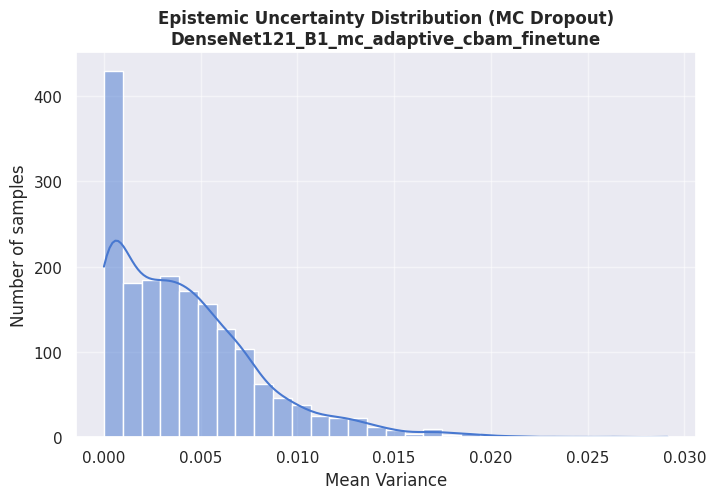

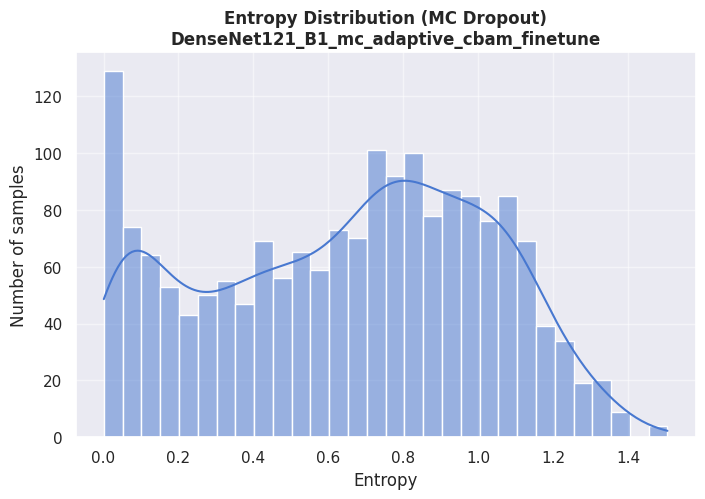

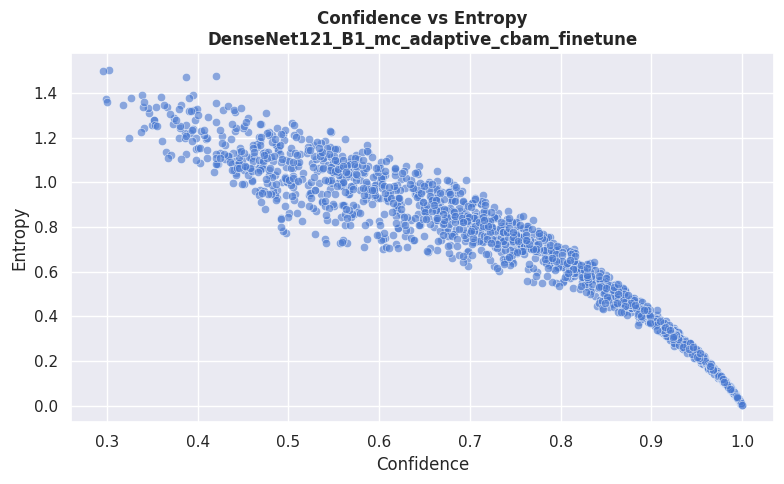

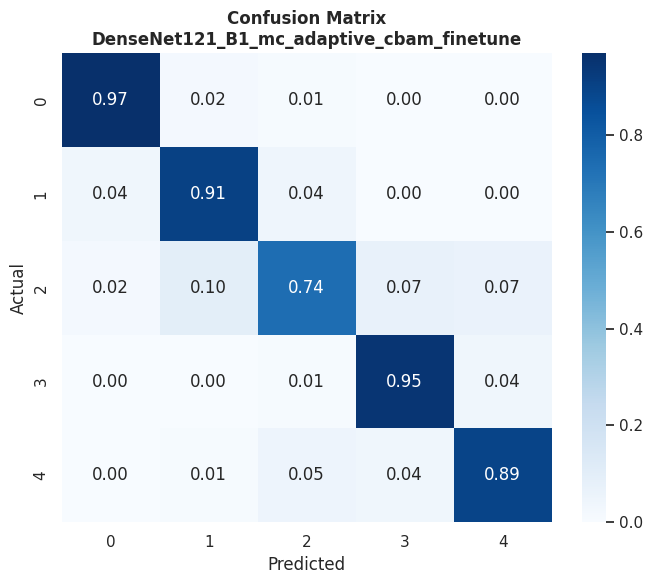

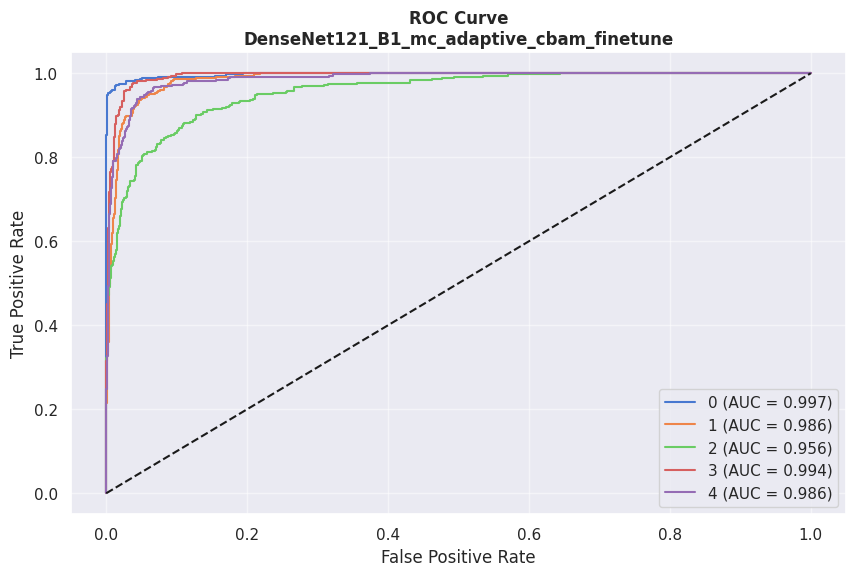

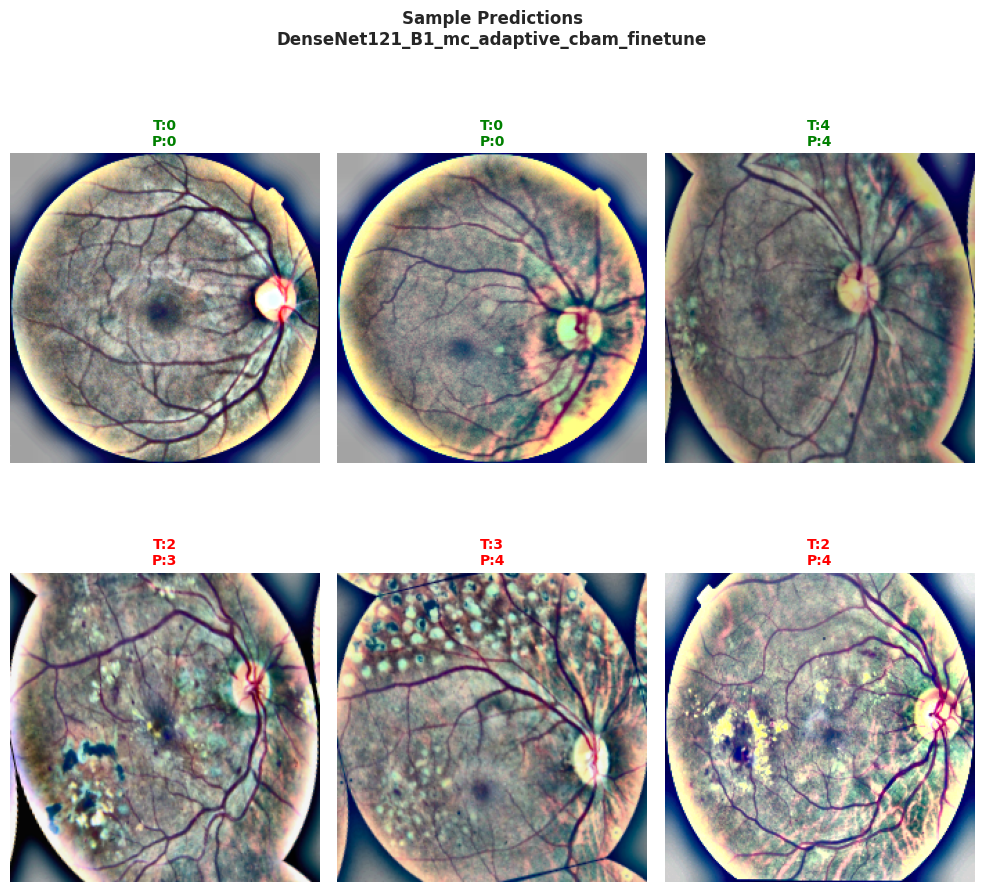


| QWK: 0.9430 | Accuracy (B): 0.8925 | Precision (Macro): 0.8916 | Recall (Macro): 0.8925 | F1 Score (Macro): 0.8908


In [ ]:
model_names = {
    # == full model (mc dropout + adaptivecbam) ==
    'DenseNet121_B1_mc_adaptive_cbam_finetune': ('B1', val_gen),
}


for name, (exp, val) in (model_names.items()):
    evaluate_test_set(name, exp, val, n_passes=25)

## Functions for Transformer Comparison

In [ ]:
def compute_mc_results(test_set, cnn_best, n_mc_passes, class_labels=None):
    if class_labels is None:
        class_labels = list(test_set.class_indices.keys())

    test_set.reset()
    y_true = test_set.classes

    mc = cnn_best.monte_carlo_dropout_full(test_set, n_passes=n_mc_passes)
    mean_pred = mc["mean_pred"]
    y_pred = np.argmax(mean_pred, axis=1)
    conf = np.max(mean_pred, axis=1)

    entropy   = mc["entropy"]
    uncertainty = mc["var_pred"].mean(axis=1)

    qwk = cohen_kappa_score(y_true, y_pred, weights="quadratic")
    f1_best = f1_score(y_true, y_pred, average="macro")
    acc_best = balanced_accuracy_score(y_true, y_pred)

    rs = cnn_best.compute_reliability_score(
        qwk=qwk,
        mean_entropy=mc["mean_entropy"],
        mean_confidence=mc["mean_confidence"],
        num_classes=len(class_labels)
    )

    print(f"\n=== Results for the BEST CNN Model ===")
    print(f"|QWK: {qwk:.4f}")
    print(f"|Accuracy (Balanced): {acc_best:.4f}")
    print(f"|F1 (Macro): {f1_best:.4f}")
    print(f"|Reliability Score (RS): {rs:.4f}")
    print(f"|Mean Entropy: {mc['mean_entropy']:.4f}")
    print(f"|Mean Confidence: {mc['mean_confidence']:.4f}")

    plt.figure(figsize=(12,5))

    ax1 = plt.subplot(1, 2, 1)
    ax1.hist(conf[y_pred == y_true], bins=30, alpha=0.6, label="Correct", color='green')
    ax1.hist(conf[y_pred != y_true], bins=30, alpha=0.6, label="Wrong", color='red')
    ax1.legend()
    ax1.set_title("CNN Confidence: Correct vs Wrong Predictions", fontsize=12, weight="bold")
    ax1.grid(alpha=0.3)

    ax2 = plt.subplot(1, 2, 2)
    ax2.hist(entropy[y_pred == y_true], bins=30, alpha=0.6, label="Correct", color='green')
    ax2.hist(entropy[y_pred != y_true], bins=30, alpha=0.6, label="Wrong", color='red')
    ax2.legend()
    ax2.set_title("CNN Entropy: Correct vs Wrong Predictions", fontsize=12, weight="bold")

    plt.tight_layout()
    plt.show()

    return {
        "mean_pred": mean_pred,
        "var_pred": mc["var_pred"],
        "entropy": entropy,
        "confidence": conf,
        "y_true": y_true,
        "y_pred": y_pred,
        "uncertainty": uncertainty,
        "class_labels": class_labels
    }

In [ ]:
def visualize_cnn_image(img_path, cnn_best, mc_results, test_set, class_labels):
    image_paths = test_set.filepaths
    filename = os.path.basename(img_path)

    idx = None
    for i, p in enumerate(image_paths):
        if os.path.basename(p) == filename:
            idx = i
            break

    if idx is None:
        raise ValueError(f"Image not found: {filename}")

    y_true = mc_results["y_true"][idx]
    y_pred = mc_results["y_pred"][idx]
    conf = mc_results["confidence"][idx]
    entropy = mc_results["entropy"][idx]

    image = Image.open(img_path).convert("RGB")
    image_np = np.array(image).astype(np.float32) / 255.0

    sal = Saliency(
        cnn_best.model,
        model_modifier=ReplaceToLinear(),
        clone=True
    )

    score = CategoricalScore([y_pred])

    sal_map = sal(
        score,
        image_np[np.newaxis, ...],
        smooth_samples=20,
        smooth_noise=0.2
    )[0]

    true_label = class_labels[y_true]
    pred_label = class_labels[y_pred]

    plt.figure(figsize=(6,4))

    plt.subplot(1,2,1)
    plt.imshow(image_np)
    plt.axis("off")
    plt.title(
        f"T: {true_label} | P: {pred_label}\n"
        f"Conf: {conf:.2f} | H: {entropy:.2f}",
        color="green" if y_true == y_pred else "red",
        fontsize=10, weight="bold")

    plt.subplot(1,2,2)
    plt.imshow(image_np)
    plt.imshow(sal_map, cmap="jet", alpha=0.7)
    plt.axis("off")
    plt.title("CNN Saliency", fontsize=12, weight="bold")

    plt.tight_layout()
    plt.show()

In [ ]:
def cnn_gradcam(cnn_model, image_np, class_idx):
    gradcam = Gradcam(
        cnn_model.model,
        model_modifier=ReplaceToLinear(),
        clone=True
    )

    score = CategoricalScore([class_idx])

    cam = gradcam(
        score,
        image_np[np.newaxis, ...],
        penultimate_layer='conv5_block16_concat'
    )[0]

    cam = np.maximum(cam, 0)
    cam = cam - cam.min()
    cam = cam / (cam.max() + 1e-8)
    cam = cv2.GaussianBlur(cam, (7, 7), 0)

    return cam

In [ ]:
def confidence_drop_cnn(cnn_best, generator, cam_func, top_k=0.1):
    drops = []
    generator.reset()

    for batch_x, _ in generator:
        preds = cnn_best.model.predict(batch_x, verbose=0)

        for i in range(batch_x.shape[0]):
            img = batch_x[i]
            pred = preds[i]

            conf_original = np.max(pred)
            pred_class = np.argmax(pred)

            # --- CAM ---
            cam = cam_func(cnn_best, img, pred_class)

            # --- Top-K mask ---
            threshold = np.quantile(cam, 1 - top_k)
            mask = (cam >= threshold).astype(np.float32)

            mask = np.repeat(mask[..., np.newaxis], 3, axis=2)

            # ❗ удаляем важное
            img_masked = img * (1 - mask)

            # --- Re-evaluate ---
            pred_masked = cnn_best.model.predict(img_masked[np.newaxis, ...], verbose=0)
            conf_masked = np.max(pred_masked)

            drop = conf_original - conf_masked
            drops.append(drop)

        if len(drops) > len(generator.filenames):
            break

    return np.mean(drops)

In [ ]:
def localization_score_cnn(cnn_best, generator, cam_func):
    scores = []

    generator.reset()

    for batch_x, _ in generator:
        preds = cnn_best.model.predict(batch_x, verbose=0)

        for i in range(batch_x.shape[0]):
            img = batch_x[i]
            pred_class = np.argmax(preds[i])

            cam = cam_func(cnn_best, img, pred_class)

            H, W = cam.shape

            # центр (можно потом поиграться)
            h_start, h_end = int(H*0.3), int(H*0.7)
            w_start, w_end = int(W*0.3), int(W*0.7)

            center = cam[h_start:h_end, w_start:w_end]

            score = center.sum() / (cam.sum() + 1e-8)
            scores.append(score)

        if len(scores) > len(generator.filenames):
            break

    return np.mean(scores)

In [ ]:
def deletion_curve_cnn(cnn_model, img, cam, steps=20):
    H, W, _ = img.shape

    cam_flat = cam.flatten()
    img_flat = img.reshape(-1, 3)
    idx = np.argsort(-cam_flat)  # descending

    scores = []
    for k in np.linspace(0, len(idx), steps).astype(int):
        img_mod = img_flat.copy()
        img_mod[idx[:k]] = 0
        img_mod = img_mod.reshape(H, W, 3)
        pred = cnn_model.predict(img_mod[np.newaxis, ...], verbose=0)
        scores.append(np.max(pred))

    return np.array(scores)

In [ ]:
def deletion_auc_cnn(cnn_best, generator, cam_func, steps=20):
    aucs = []

    generator.reset()

    for batch_x, _ in generator:
        preds = cnn_best.model.predict(batch_x, verbose=0)

        for i in range(batch_x.shape[0]):
            img = batch_x[i]
            pred_class = np.argmax(preds[i])

            cam = cam_func(cnn_best, img, pred_class)

            curve = deletion_curve_cnn(cnn_best.model, img, cam, steps)

            # --- Normalize x-axis ---
            x = np.linspace(0, 1, len(curve))

            auc = np.trapz(curve, x)
            aucs.append(auc)

        if len(aucs) > len(generator.filenames):
            break

    return np.mean(aucs)

In [ ]:
def energy_concentration_cnn(cnn_best, generator, cam_func, top_k=0.1):
    scores = []

    generator.reset()

    for batch_x, _ in generator:
        preds = cnn_best.model.predict(batch_x, verbose=0)

        for i in range(batch_x.shape[0]):
            img = batch_x[i]
            pred_class = np.argmax(preds[i])

            cam = cam_func(cnn_best, img, pred_class)

            # --- Normalize CAM ---
            cam = cam / (cam.sum() + 1e-8)

            # --- Top-K threshold ---
            threshold = np.quantile(cam, 1 - top_k)

            important_energy = cam[cam >= threshold].sum()
            total_energy = cam.sum()

            score = important_energy / (total_energy + 1e-8)
            scores.append(score)

        if len(scores) > len(generator.filenames):
            break

    return np.mean(scores)

In [ ]:
cnn_best = CNN_build()
cnn_best.load_model("DenseNet121_B1_mc_adaptive_cbam_finetune_best_by_kappa")


--- Model loaded for DenseNet121_B1_mc_adaptive_cbam_finetune_best_by_kappa ---



--- MC Dropout inference: 25 stochastic passes ---
Pass 1/25
Pass 2/25
Pass 3/25
Pass 4/25
Pass 5/25
Pass 6/25
Pass 7/25
Pass 8/25
Pass 9/25
Pass 10/25
Pass 11/25
Pass 12/25
Pass 13/25
Pass 14/25
Pass 15/25
Pass 16/25
Pass 17/25
Pass 18/25
Pass 19/25
Pass 20/25
Pass 21/25
Pass 22/25
Pass 23/25
Pass 24/25
Pass 25/25

=== Results for the BEST CNN Model ===
|QWK: 0.9138
|Accuracy (Balanced): 0.8643
|F1 (Macro): 0.8620
|Reliability Score (RS): 0.6117
|Mean Entropy: 0.6466
|Mean Confidence: 0.7489


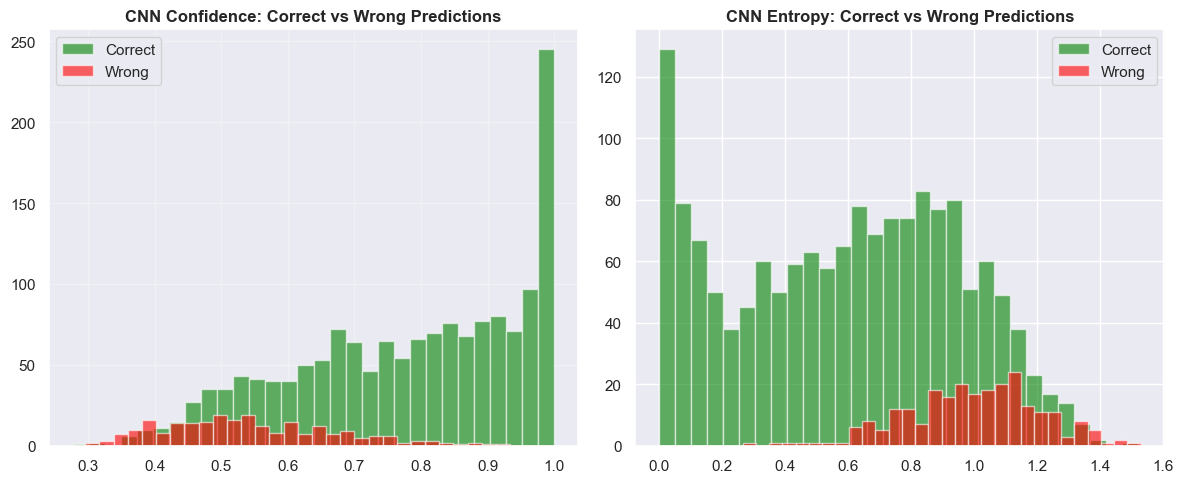

In [ ]:
mc_cnn = compute_mc_results(
    test_set=val_gen,
    cnn_best=cnn_best,
    n_mc_passes=25,
    class_labels=list(val_gen.class_indices.keys())
)

In [ ]:
for i in range(10):
    img_path = val_gen.filepaths[i]

    print(f"\nIMAGE: {img_path}\n")

    visualize_cnn_image(
        img_path=img_path,
        cnn_best=cnn_best,
        mc_results=mc_cnn,
        test_set=val_gen,
        class_labels=list(val_gen.class_indices.keys())
    )

In [ ]:
auc_cnn = deletion_auc_cnn(
    cnn_best,
    val_gen,
    cam_func=cnn_gradcam,
    steps=20
)

print(f"CNN Deletion AUC: {auc_cnn:.4f}")


C:\Users\eliza\AppData\Local\Temp\ipykernel_4788\1279725502.py:20: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc = np.trapz(curve, x)


In [ ]:
energy_cnn = energy_concentration_cnn(
    cnn_best,
    val_gen,
    cam_func=cnn_gradcam,
    top_k=0.1
)

print(f"CNN Energy Concentration: {energy_cnn:.4f}")

CNN Energy Concentration: 0.3968
